# Logistic Regression — An Illustrated Tour

> Linear regression predicts *numbers*. **Logistic Regression** predicts *probabilities* — which class does this point belong to?

---

**What we cover:**
- The classification problem and why linear regression fails
- The sigmoid function — squashing scores into probabilities
- The decision boundary
- Log-loss cost and gradient descent
- Regularisation (C parameter)
- Confusion matrix, ROC-AUC, and key metrics

## The picture — the sigmoid squashes a linear score into a probability

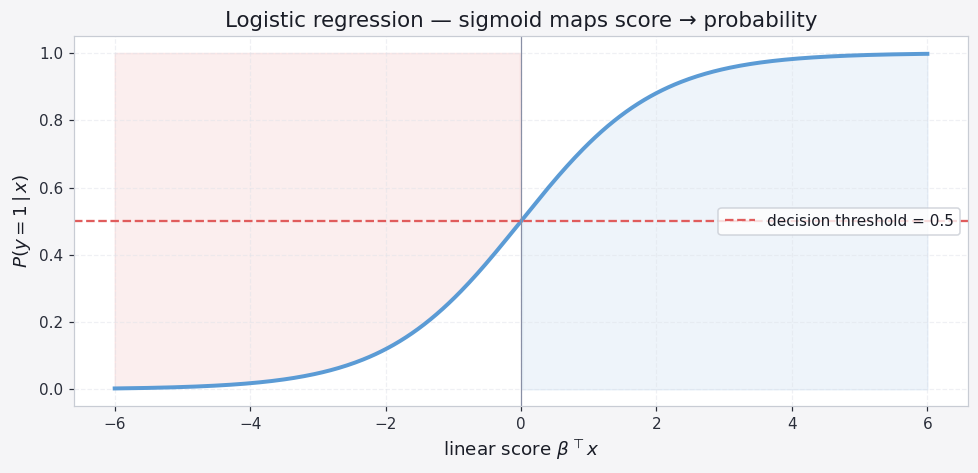

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
z = np.linspace(-6, 6, 400); s = 1/(1+np.exp(-z))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(z, s, color=P[0], lw=2.6)
ax.axhline(0.5, color=P[1], ls='--', label='decision threshold = 0.5')
ax.axvline(0, color='#888fa5', lw=0.8)
ax.fill_between(z, 0, s, where=(z>0), alpha=0.10, color=P[0])
ax.fill_between(z, s, 1, where=(z<0), alpha=0.10, color=P[1])
ax.set_xlabel(r'linear score $\beta^\top x$'); ax.set_ylabel(r'$P(y=1\,|\,x)$')
ax.set_title('Logistic regression — sigmoid maps score → probability')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              classification_report, accuracy_score)

# ── Presentation style ─────────────────────────────────────────────────────
PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C0 = '#5b9bd5'    # class 0 — blue
C1 = '#e05c5c'    # class 1 — coral
CB = '#f4b942'    # boundary — amber
CM = '#7ecba1'    # metric / mint
CH = '#56b6c2'    # highlight — cyan
CP = '#c678dd'    # purple

# ── 2-D dataset for boundary plots ─────────────────────────────────────────
np.random.seed(42)
X2, y2 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                              n_informative=2, random_state=42,
                              n_clusters_per_class=1)
scaler2 = StandardScaler()
X2s = scaler2.fit_transform(X2)

# ── High-dim dataset for metrics ───────────────────────────────────────────
X, y = make_classification(n_samples=200, n_features=20,
                            n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s  = scaler.transform(X_te)

print('2-D dataset:    200 samples, 2 features')
print('Full dataset:  1000 samples, 20 features')

2-D dataset:    200 samples, 2 features
Full dataset:  1000 samples, 20 features


---
## The Classification Problem

Instead of predicting a continuous value, we predict **which class** a point belongs to.
Linear regression gives raw scores — they can be negative or > 1 — which don't work as probabilities.

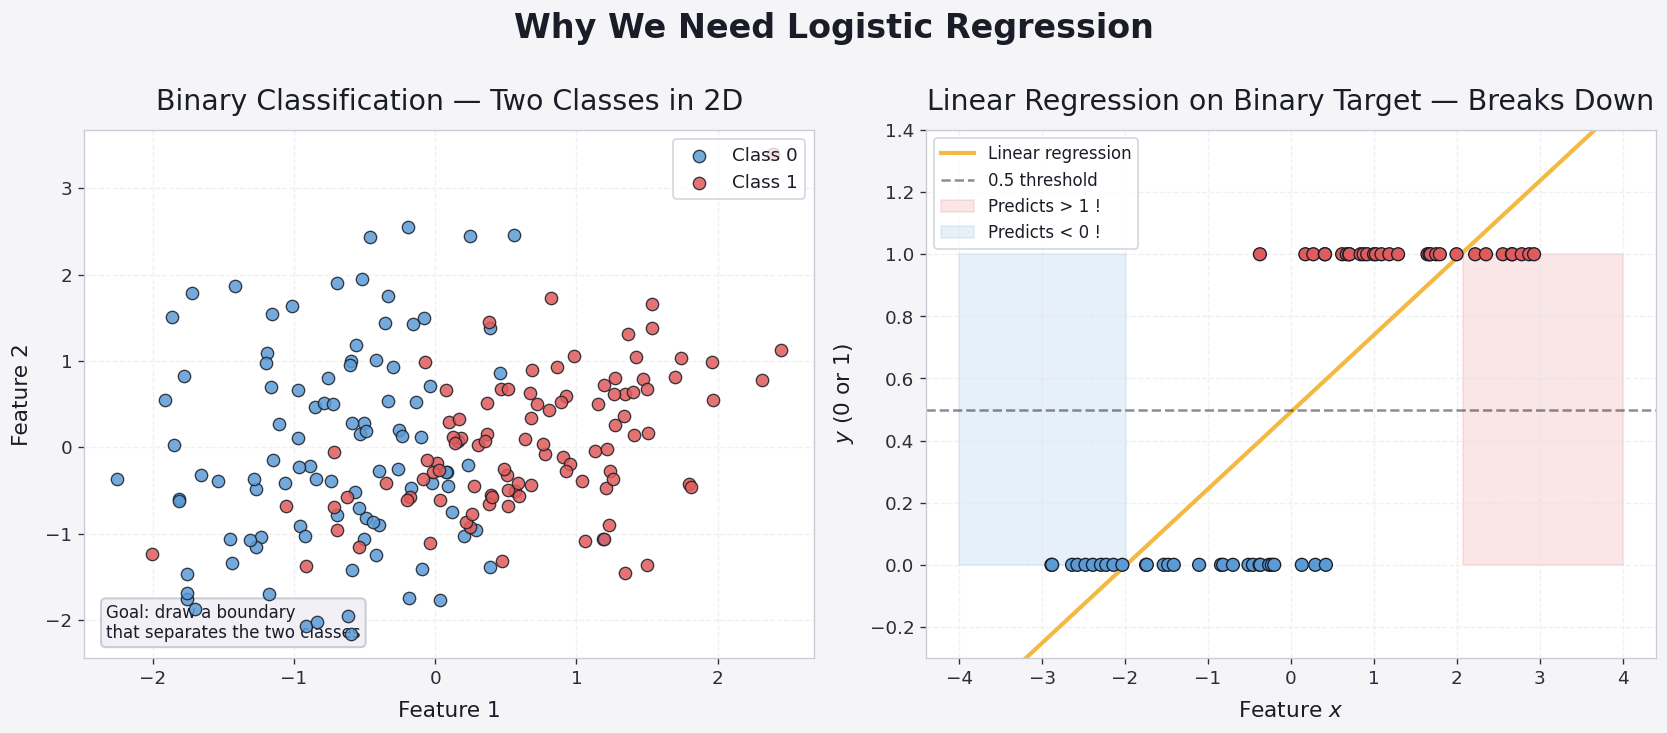

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: 2D scatter
ax = axes[0]
for cls, col, lbl in [(0, C0, 'Class 0'), (1, C1, 'Class 1')]:
    mask = y2 == cls
    ax.scatter(X2s[mask, 0], X2s[mask, 1], c=col, s=55,
               edgecolors='#1a1d27', lw=0.8, alpha=0.85, label=lbl, zorder=4)
ax.set_xlabel('Feature 1', labelpad=8); ax.set_ylabel('Feature 2', labelpad=8)
ax.set_title('Binary Classification — Two Classes in 2D', pad=12)
ax.legend(loc='upper right'); ax.grid(True)
ax.text(0.03, 0.03, 'Goal: draw a boundary\nthat separates the two classes',
        transform=ax.transAxes, fontsize=10, va='bottom',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec='#c8ccd4', lw=1.2))

# Right: why not linear regression on a binary target?
ax = axes[1]
np.random.seed(0)
x1d = np.sort(np.random.uniform(-3, 3, 60))
y1d = (x1d + np.random.randn(60) * 0.4 > 0).astype(float)

# OLS fit
from numpy.polynomial import polynomial as P
ols_coef = np.polyfit(x1d, y1d, 1)
x_line   = np.linspace(-4, 4, 200)
y_ols    = np.polyval(ols_coef, x_line)

ax.scatter(x1d, y1d, c=[C1 if yi else C0 for yi in y1d],
           s=60, edgecolors='#1a1d27', lw=0.8, zorder=4)
ax.plot(x_line, y_ols, color=CB, lw=2.5, label='Linear regression')
ax.axhline(0.5, color='#1a1d27', ls='--', lw=1.5, alpha=0.5, label='0.5 threshold')
ax.fill_between(x_line, 0, 1, where=(y_ols > 1), color=C1, alpha=0.15,
                label='Predicts > 1 !')
ax.fill_between(x_line, 0, 1, where=(y_ols < 0), color=C0, alpha=0.15,
                label='Predicts < 0 !')
ax.set_ylim(-0.3, 1.4)
ax.set_xlabel('Feature $x$', labelpad=8); ax.set_ylabel('$y$ (0 or 1)', labelpad=8)
ax.set_title('Linear Regression on Binary Target — Breaks Down', pad=12)
ax.legend(loc='upper left', fontsize=10); ax.grid(True)

fig.suptitle('Why We Need Logistic Regression', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## The Sigmoid Function

Logistic regression pipes the linear score $z = \theta^T x$ through the **sigmoid** (logistic) function:

$$h_\theta(x) = \sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1)$$

The output is always between 0 and 1 — a valid probability. We interpret it as:
$$P(y=1 \mid x;\, \theta) = \sigma(\theta^T x)$$

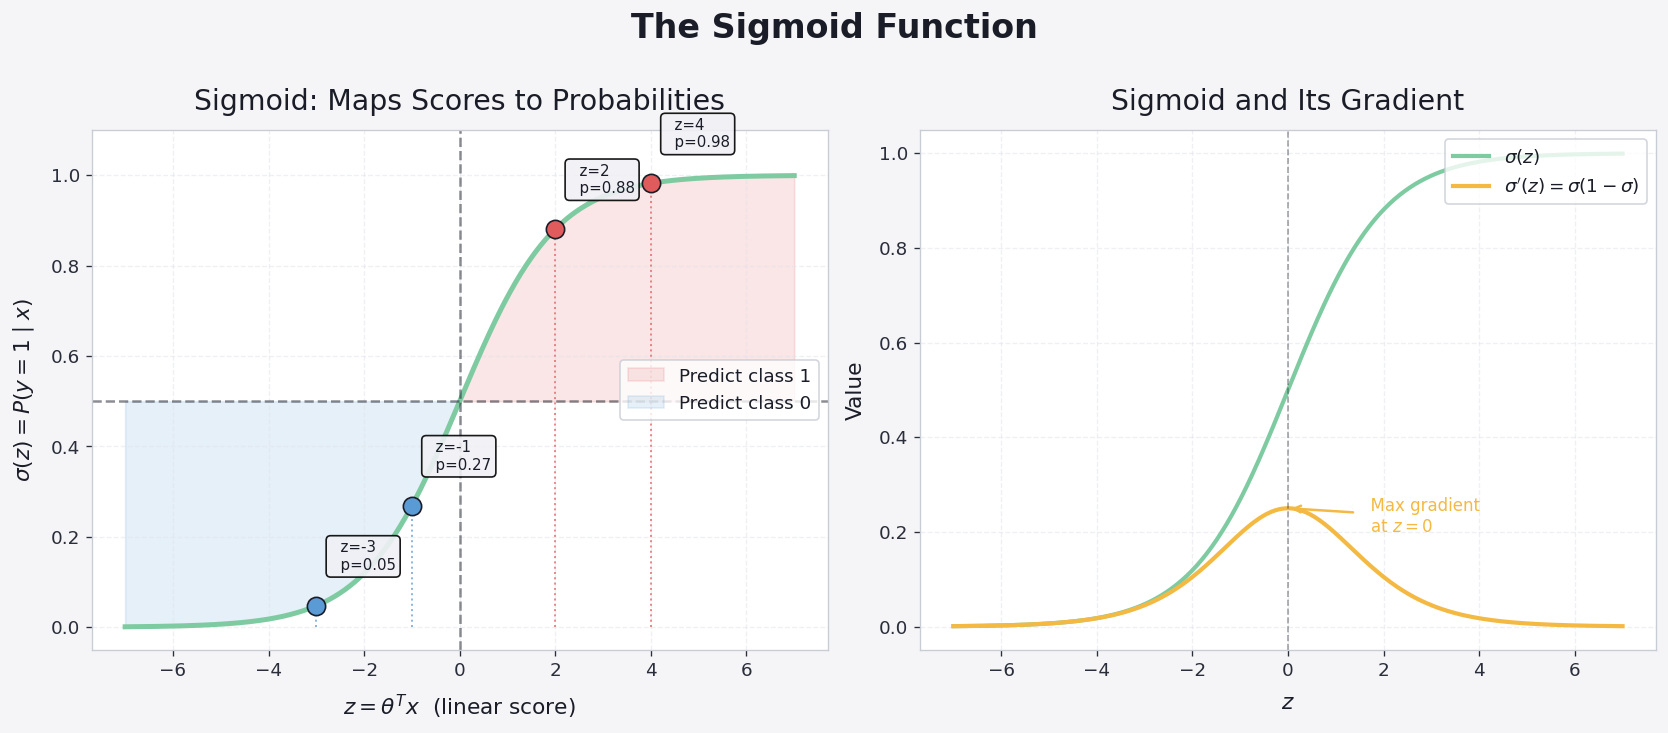

In [4]:
z = np.linspace(-7, 7, 400)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: sigmoid curve
ax = axes[0]
ax.plot(z, sigmoid, color=CM, lw=3)
ax.axhline(0.5, color='#1a1d27', ls='--', lw=1.5, alpha=0.5)
ax.axvline(0,   color='#1a1d27', ls='--', lw=1.5, alpha=0.5)
ax.fill_between(z, 0.5, sigmoid, where=(z > 0), color=C1, alpha=0.15,
                label='Predict class 1')
ax.fill_between(z, sigmoid, 0.5, where=(z < 0), color=C0, alpha=0.15,
                label='Predict class 0')
for z_ex, col in [(-3, C0), (-1, C0), (2, C1), (4, C1)]:
    p = 1/(1+np.exp(-z_ex))
    ax.scatter([z_ex], [p], s=120, c=col, zorder=6, edgecolors='#1a1d27', lw=1)
    ax.plot([z_ex, z_ex], [0, p], color=col, lw=1.2, ls=':', alpha=0.7)
    ax.annotate(f'  z={z_ex}\n  p={p:.2f}',
                xy=(z_ex, p), xytext=(z_ex+0.3, p+0.08),
                fontsize=9, color='#1a1d27',
                bbox=dict(boxstyle='round,pad=0.3', fc='#f0f0f5', alpha=0.9))
ax.set_xlabel('$z = \\theta^T x$  (linear score)', labelpad=8)
ax.set_ylabel('$\\sigma(z) = P(y=1 \\mid x)$', labelpad=8)
ax.set_title('Sigmoid: Maps Scores to Probabilities', pad=12)
ax.legend(loc='center right'); ax.grid(True); ax.set_ylim(-0.05, 1.1)

# Right: sigmoid derivative (gradient)
ax = axes[1]
dsigmoid = sigmoid * (1 - sigmoid)
ax.plot(z, sigmoid,  color=CM,   lw=2.5, label="$\\sigma(z)$")
ax.plot(z, dsigmoid, color=CB,   lw=2.5, label="$\\sigma'(z) = \\sigma(1-\\sigma)$")
ax.axvline(0, color='#1a1d27', ls='--', lw=1, alpha=0.4)
ax.annotate('  Max gradient\n  at $z=0$',
            xy=(0, 0.25), xytext=(1.5, 0.20),
            fontsize=10, color=CB,
            arrowprops=dict(arrowstyle='->', color=CB, lw=1.5))
ax.set_xlabel('$z$', labelpad=8); ax.set_ylabel('Value', labelpad=8)
ax.set_title('Sigmoid and Its Gradient', pad=12)
ax.legend(loc='upper right'); ax.grid(True)

fig.suptitle('The Sigmoid Function', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## The Decision Boundary

We predict class 1 when $P(y=1 \mid x) \geq 0.5$, i.e. when $\theta^T x \geq 0$.
The **decision boundary** is the line (or hyperplane) $\theta^T x = 0$ where the model is exactly 50% confident.

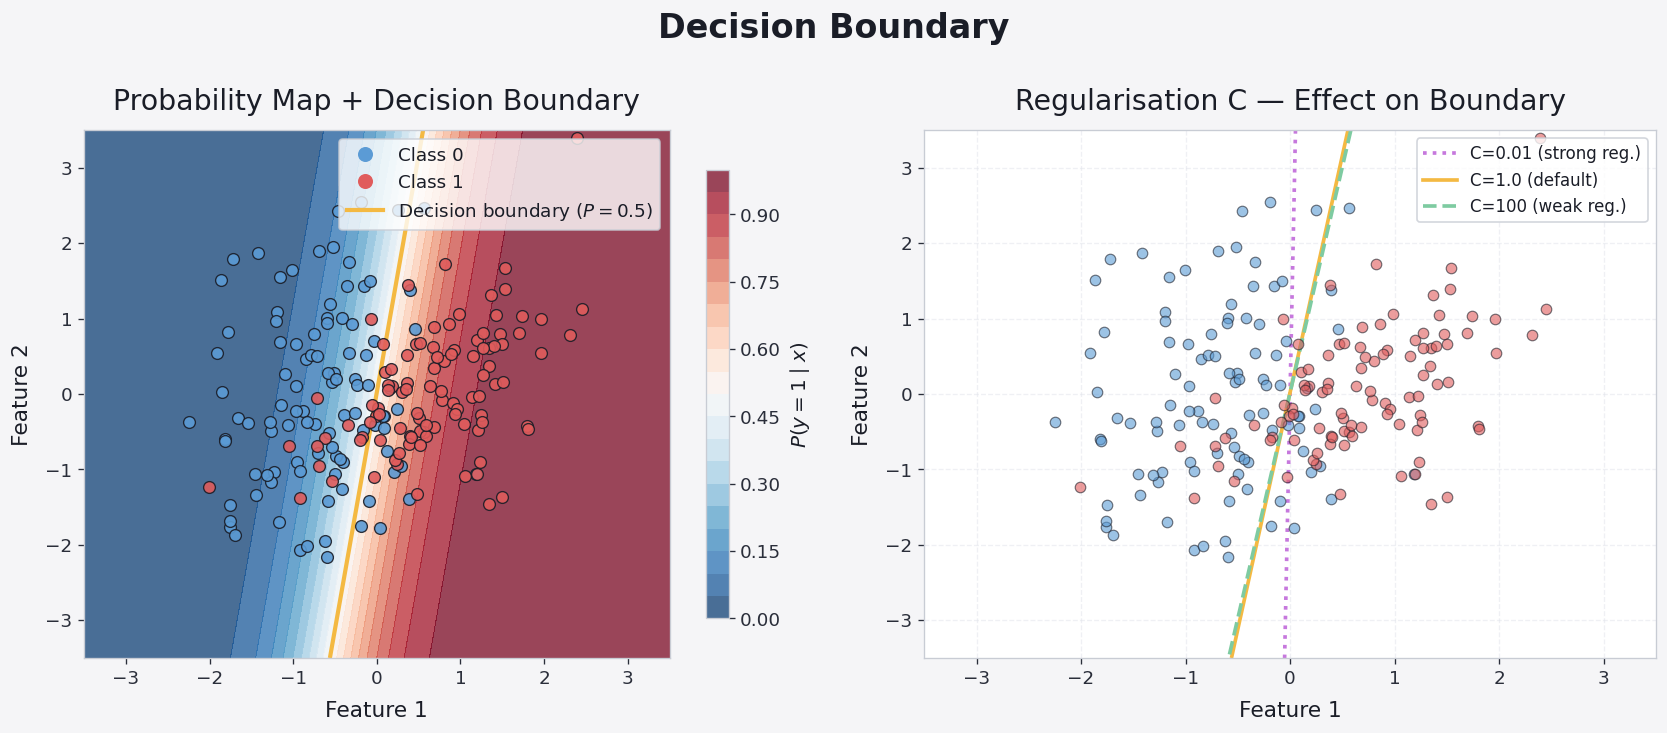

In [5]:
clf = LogisticRegression(C=1.0, max_iter=1000)
clf.fit(X2s, y2)

xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 300),
                     np.linspace(-3.5, 3.5, 300))
ZZ = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: probability heatmap + decision boundary
ax = axes[0]
im = ax.contourf(xx, yy, ZZ, levels=20, cmap='RdBu_r', alpha=0.75)
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('$P(y=1 \\mid x)$', fontsize=12)
cbar.ax.tick_params(labelcolor='#2a2e3a')
ax.contour(xx, yy, ZZ, levels=[0.5], colors=CB, linewidths=2.5)
for cls, col, lbl in [(0, C0, 'Class 0'), (1, C1, 'Class 1')]:
    mask = y2 == cls
    ax.scatter(X2s[mask,0], X2s[mask,1], c=col, s=50,
               edgecolors='#1a1d27', lw=0.8, alpha=0.9, label=lbl, zorder=5)
ax.set_xlabel('Feature 1', labelpad=8); ax.set_ylabel('Feature 2', labelpad=8)
ax.set_title('Probability Map + Decision Boundary', pad=12)
ax.legend(loc='upper right'); ax.grid(False)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color=C0, marker='o', ms=8, ls='', label='Class 0'),
    Line2D([0],[0], color=C1, marker='o', ms=8, ls='', label='Class 1'),
    Line2D([0],[0], color=CB, lw=2.5, label='Decision boundary ($P=0.5$)'),
], loc='upper right')

# Right: different C values → different boundaries
ax = axes[1]
for cls, col in [(0, C0), (1, C1)]:
    mask = y2 == cls
    ax.scatter(X2s[mask,0], X2s[mask,1], c=col, s=40,
               edgecolors='#1a1d27', lw=0.7, alpha=0.6, zorder=3)

for C_val, col, ls, lbl in [
    (0.01, CP,  ':',  'C=0.01  (strong reg.)'),
    (1.0,  CB,  '-',  'C=1.0   (default)'),
    (100,  CM,  '--', 'C=100   (weak reg.)'),
]:
    clf_c = LogisticRegression(C=C_val, max_iter=1000)
    clf_c.fit(X2s, y2)
    ZZ_c  = clf_c.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contour(xx, yy, ZZ_c, levels=[0.5], colors=[col], linewidths=2.2,
               linestyles=[ls])
    from matplotlib.lines import Line2D

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color=CP, lw=2.2, ls=':', label='C=0.01 (strong reg.)'),
    Line2D([0],[0], color=CB, lw=2.2, ls='-', label='C=1.0 (default)'),
    Line2D([0],[0], color=CM, lw=2.2, ls='--', label='C=100 (weak reg.)'),
], loc='upper right', fontsize=10)
ax.set_xlabel('Feature 1', labelpad=8); ax.set_ylabel('Feature 2', labelpad=8)
ax.set_title('Regularisation C — Effect on Boundary', pad=12)
ax.grid(True)

fig.suptitle('Decision Boundary', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Visual Sweep — Regularisation Strength $C$

`C` is the **inverse** of regularisation strength: small $C$ = strong penalty = the model prefers small weights = smooth, low-confidence boundary; large $C$ = weak penalty = the model is free to make the boundary as confident as the data allows.

The grid below shows the **probability heatmap** for six values of $C$ spanning strong to weak regularisation. Watch how the boundary sharpens and the weight norm $\|\theta\|_2$ grows as $C$ increases. The follow-up plot tracks $\|\theta\|_2$ across the full $C$ range.


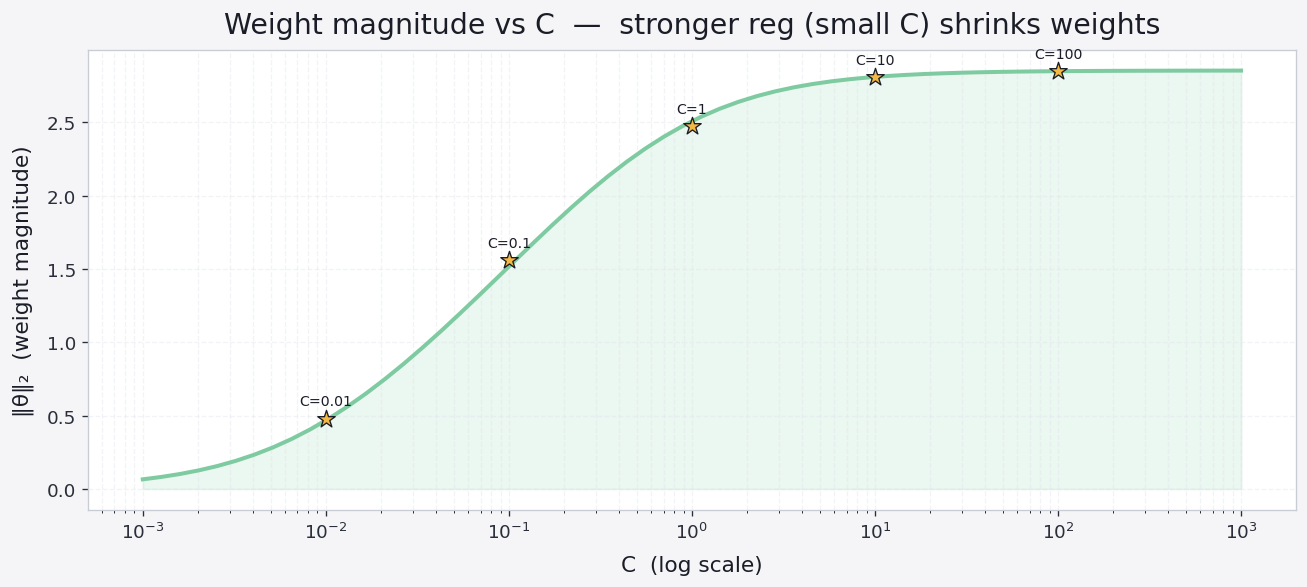

In [6]:
_C_panel = [0.01, 0.1, 1.0, 10.0, 100.0]

# Weight-norm trajectory across the full C range
_Cs    = np.logspace(-3, 3, 60)
_norms = []
for _c in _Cs:
    _c_clf = LogisticRegression(C=_c, max_iter=2000).fit(X2s, y2)
    _norms.append(np.linalg.norm(_c_clf.coef_[0]))
_norms = np.array(_norms)

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogx(_Cs, _norms, color=CM, lw=2.4)
ax.fill_between(_Cs, 0, _norms, color=CM, alpha=0.15)
for _c in _C_panel:
    _n = _norms[np.argmin(np.abs(_Cs - _c))]
    ax.scatter([_c], [_n], s=120, c=CB, marker='*',
               edgecolors='#1a1d27', lw=0.8, zorder=6)
    ax.annotate(f'C={_c:g}', (_c, _n), xytext=(0, 8),
                textcoords='offset points', ha='center',
                fontsize=8.5, color='#1a1d27')
ax.set_xlabel('C  (log scale)', labelpad=8)
ax.set_ylabel('‖θ‖₂  (weight magnitude)', labelpad=8)
ax.set_title('Weight magnitude vs C  —  stronger reg (small C) shrinks weights', pad=10)
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout(); plt.show()


---
## Cost Function — Log-Loss (Cross-Entropy)

For each training example, the cost penalises **wrong confident predictions** heavily:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^m \left[ y^{(i)} \log h_\theta(x^{(i)}) + (1-y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]$$

- If $y=1$ and $h \approx 1$: cost $\approx 0$ ✓
- If $y=1$ and $h \approx 0$: cost $\to \infty$ ✗

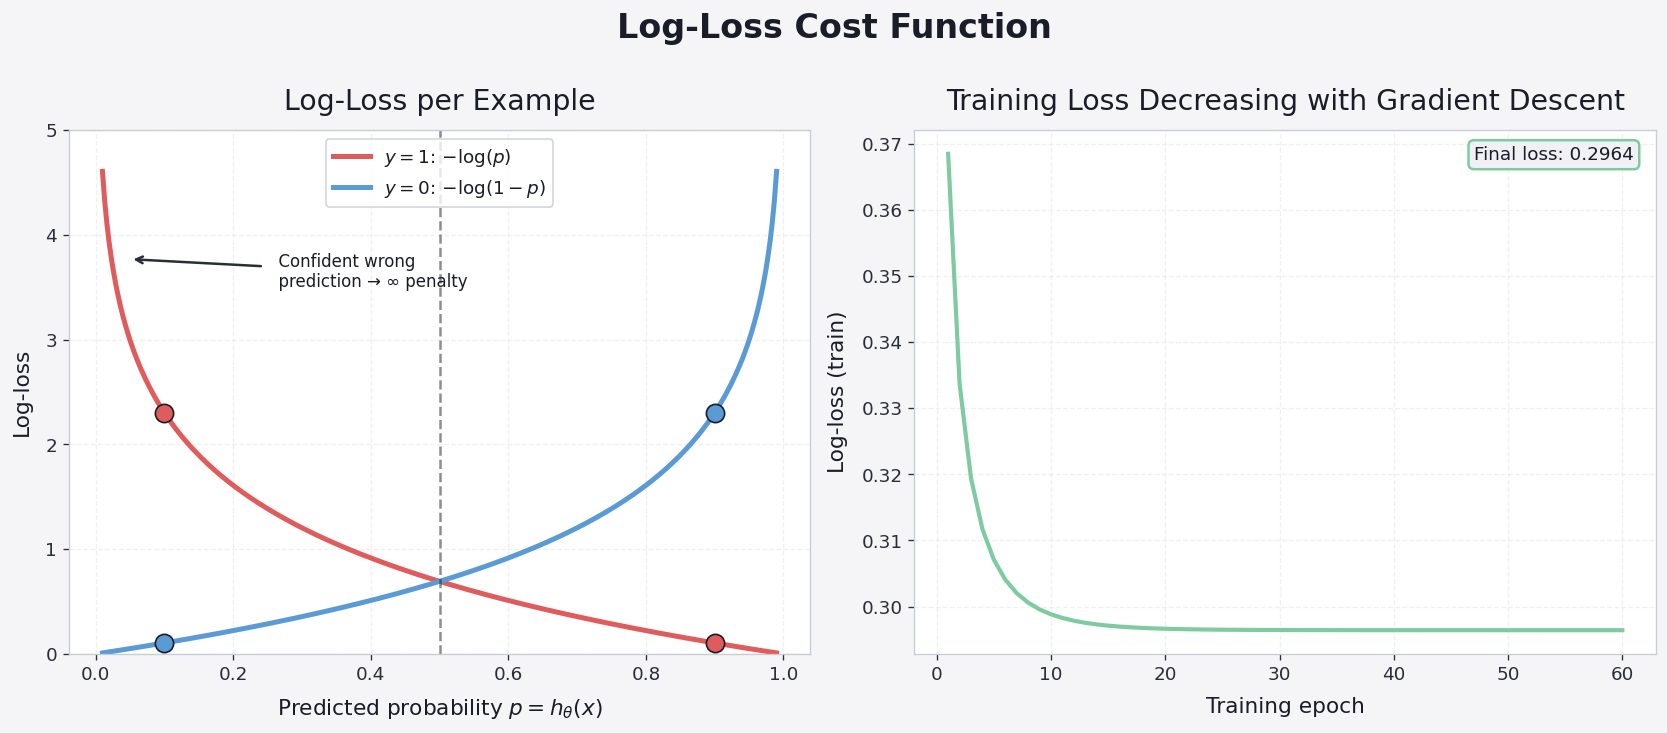

In [7]:
p = np.linspace(0.01, 0.99, 300)
loss_y1 = -np.log(p)
loss_y0 = -np.log(1 - p)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: loss curves
ax = axes[0]
ax.plot(p, loss_y1, color=C1, lw=3, label='$y=1$: $-\\log(p)$')
ax.plot(p, loss_y0, color=C0, lw=3, label='$y=0$: $-\\log(1-p)$')
ax.axvline(0.5, color='#1a1d27', ls='--', lw=1.5, alpha=0.5)
for px, col, y_true in [(0.9, C1, 1), (0.1, C1, 1), (0.1, C0, 0), (0.9, C0, 0)]:
    loss = -np.log(px) if y_true == 1 else -np.log(1-px)
    marker_col = C1 if y_true == 1 else C0
    ax.scatter([px], [loss], s=120, c=marker_col, zorder=6, edgecolors='#1a1d27', lw=1)
ax.annotate('  Confident wrong\n  prediction → ∞ penalty',
            xy=(0.05, loss_y1[4]), xytext=(0.25, 3.5),
            fontsize=10, color='#1a1d27',
            arrowprops=dict(arrowstyle='->', color='#2a2e3a', lw=1.5))
ax.set_xlabel('Predicted probability $p = h_\\theta(x)$', labelpad=8)
ax.set_ylabel('Log-loss', labelpad=8)
ax.set_title('Log-Loss per Example', pad=12)
ax.set_ylim(0, 5); ax.legend(loc='upper center'); ax.grid(True)

# Right: training loss curve (gradient descent progress)
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

loss_history = []
clf_sgd = SGDClassifier(loss='log_loss', learning_rate='constant',
                         eta0=0.05, max_iter=1, warm_start=True,
                         random_state=0, shuffle=True)
for epoch in range(60):
    clf_sgd.partial_fit(X_tr_s, y_tr, classes=[0,1])
    loss_history.append(log_loss(y_tr, clf_sgd.predict_proba(X_tr_s)))

ax = axes[1]
ax.plot(range(1, 61), loss_history, color=CM, lw=2.5)
ax.set_xlabel('Training epoch', labelpad=8)
ax.set_ylabel('Log-loss (train)', labelpad=8)
ax.set_title('Training Loss Decreasing with Gradient Descent', pad=12)
ax.grid(True)
ax.text(0.97, 0.97, f'Final loss: {loss_history[-1]:.4f}',
        transform=ax.transAxes, fontsize=11, va='top', ha='right',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=CM, lw=1.5))

fig.suptitle('Log-Loss Cost Function', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Metrics — Confusion Matrix & ROC Curve

For binary classification, a **confusion matrix** shows four outcomes:

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | True Negative (TN) | False Positive (FP) |
| **Actual 1** | False Negative (FN) | True Positive (TP) |

The **ROC curve** plots True Positive Rate vs False Positive Rate across all thresholds.

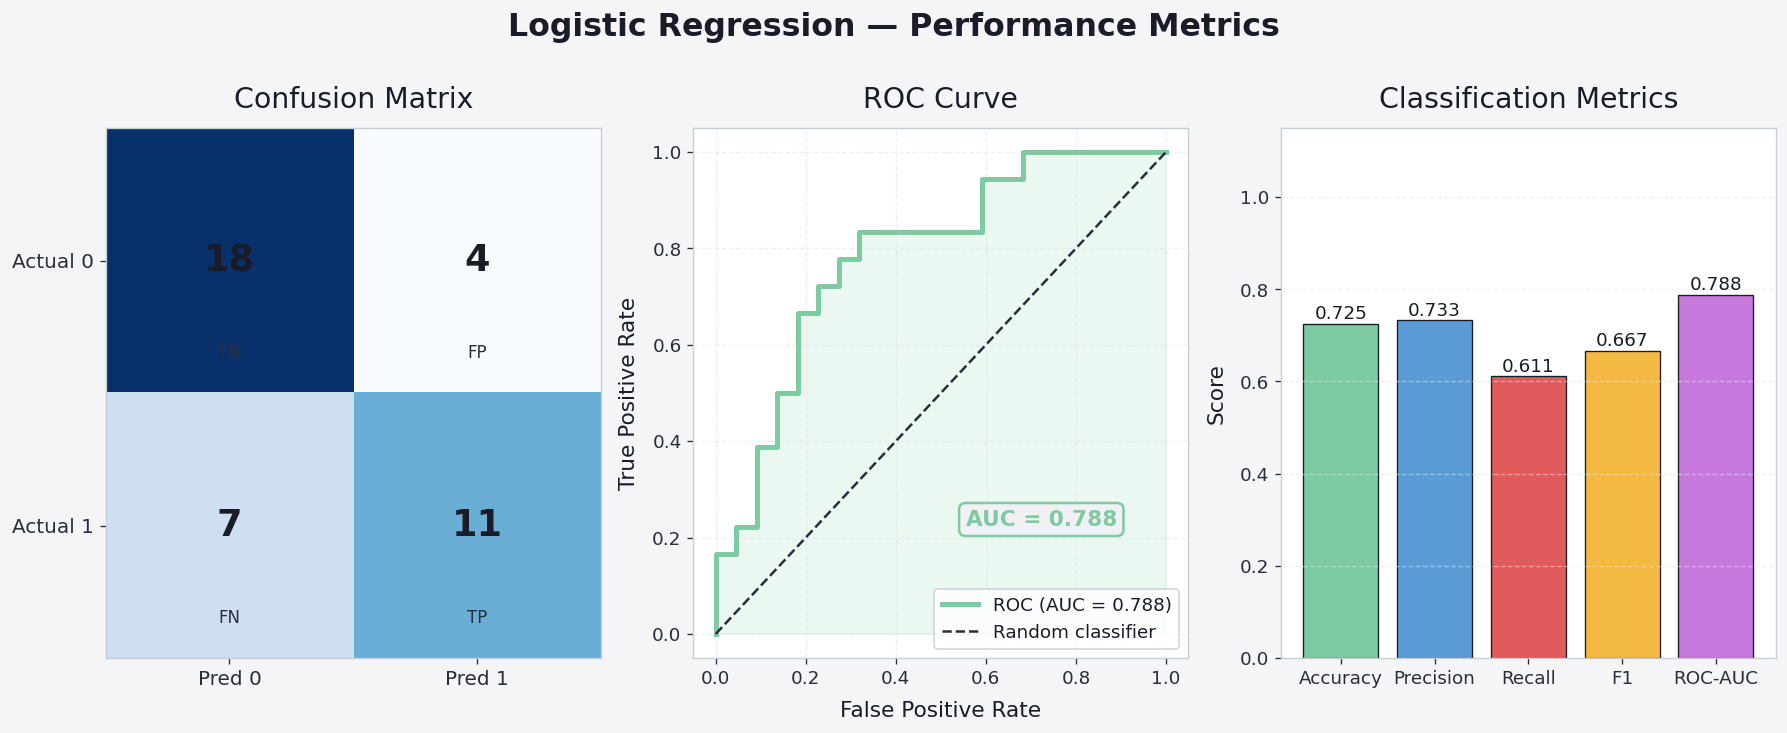

In [8]:
clf_final = LogisticRegression(C=1.0, max_iter=1000)
clf_final.fit(X_tr_s, y_tr)
preds    = clf_final.predict(X_te_s)
probs    = clf_final.predict_proba(X_te_s)[:, 1]
cm       = confusion_matrix(y_te, preds)
fpr, tpr, _ = roc_curve(y_te, probs)
roc_auc  = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Left: confusion matrix
ax = axes[0]
im = ax.imshow(cm, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=22, fontweight='bold',
                color='#1a1d27' if cm[i,j] > cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=12)
ax.set_yticklabels(['Actual 0', 'Actual 1'], fontsize=12)
ax.set_title('Confusion Matrix', pad=12)
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.35, labels[i][j], ha='center', va='center',
                fontsize=10, color='#2a2e3a')

# Middle: ROC curve
ax = axes[1]
ax.plot(fpr, tpr, color=CM, lw=3, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1.5, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.set_xlabel('False Positive Rate', labelpad=8)
ax.set_ylabel('True Positive Rate', labelpad=8)
ax.set_title('ROC Curve', pad=12)
ax.legend(loc='lower right'); ax.grid(True)
ax.text(0.55, 0.25, f'AUC = {roc_auc:.3f}',
        transform=ax.transAxes, fontsize=13, color=CM, fontweight='bold',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=CM, lw=1.5))

# Right: metrics bar
ax = axes[2]
from sklearn.metrics import precision_score, recall_score, f1_score
metrics_vals = {
    'Accuracy':  accuracy_score(y_te, preds),
    'Precision': precision_score(y_te, preds),
    'Recall':    recall_score(y_te, preds),
    'F1':        f1_score(y_te, preds),
    'ROC-AUC':   roc_auc,
}
cols_bar = [CM, C0, C1, CB, CP]
bars = ax.bar(list(metrics_vals.keys()), list(metrics_vals.values()),
              color=cols_bar, edgecolor='#1a1d27', lw=0.8)
for bar, val in zip(bars, metrics_vals.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, color='#1a1d27')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', labelpad=8)
ax.set_title('Classification Metrics', pad=12)
ax.grid(True, axis='y')

fig.suptitle('Logistic Regression — Performance Metrics', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

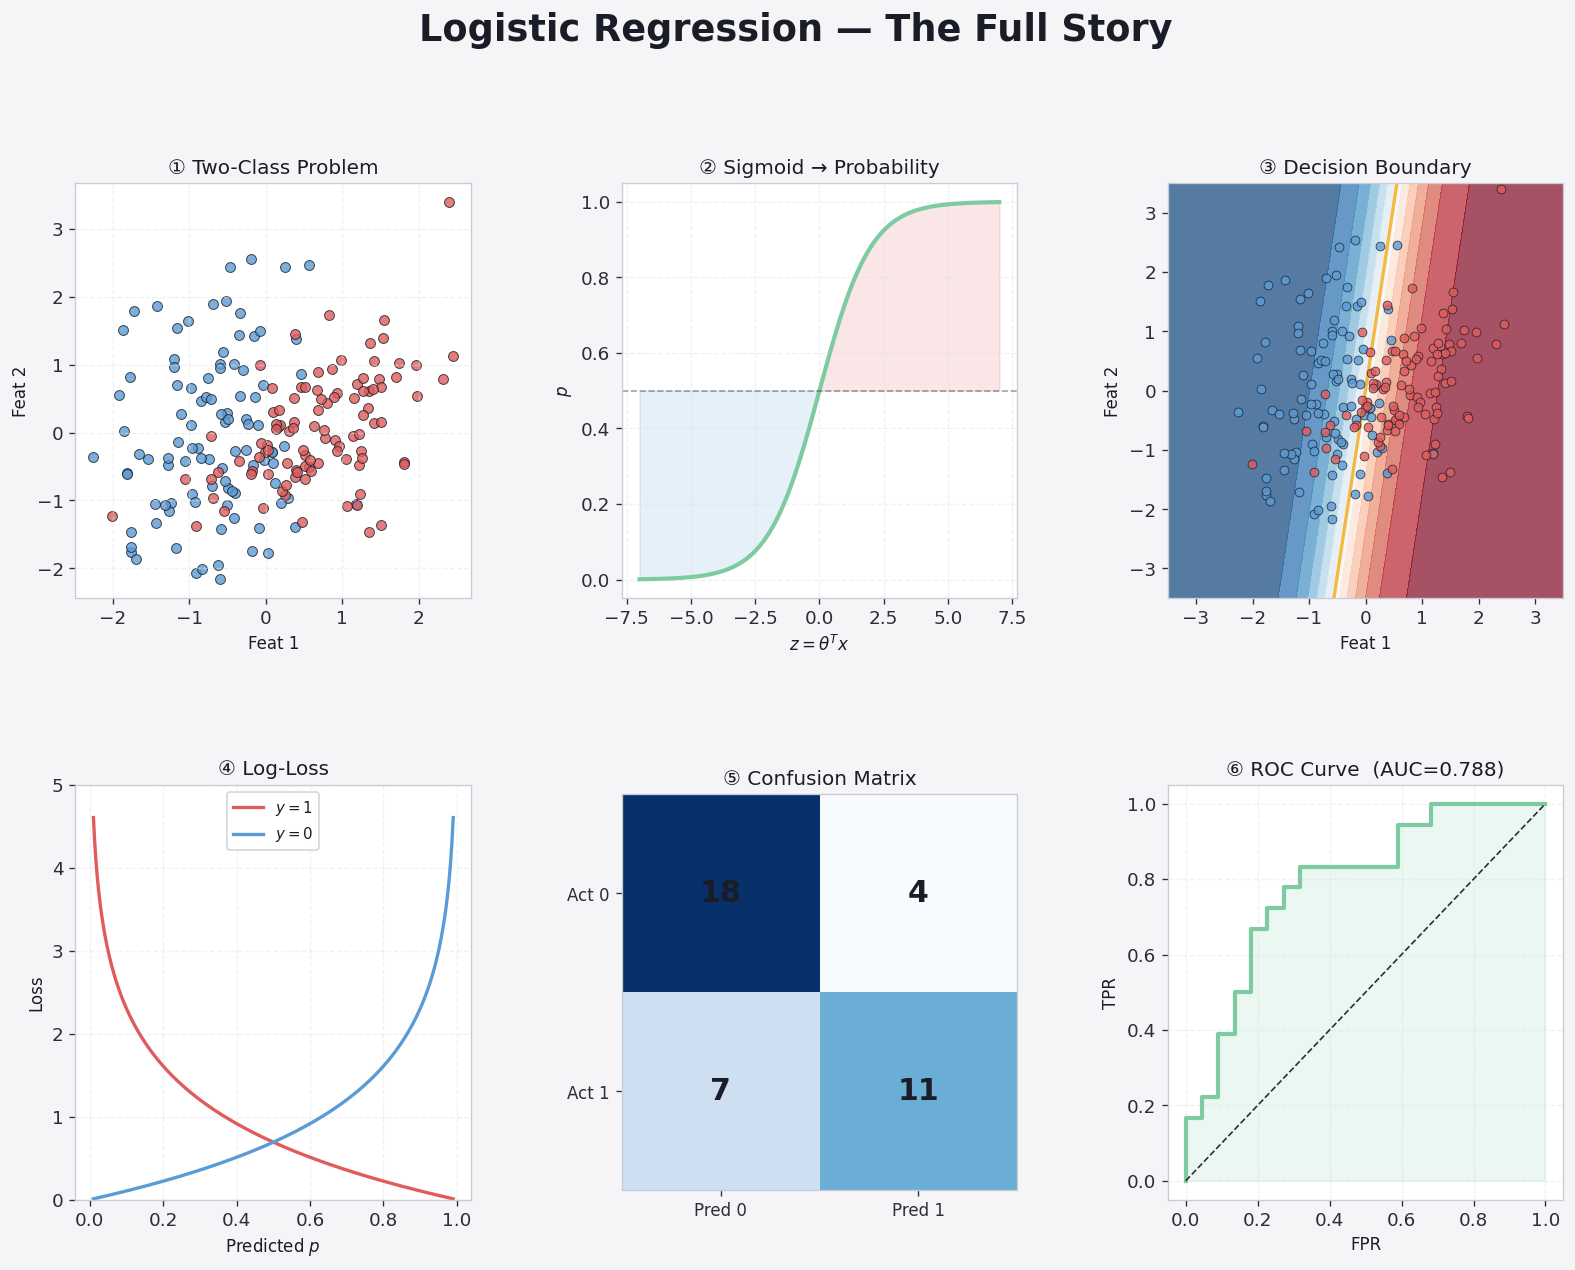

In [9]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── (0,0) 2D scatter ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for cls, col in [(0, C0), (1, C1)]:
    m = y2 == cls
    ax.scatter(X2s[m,0], X2s[m,1], c=col, s=35, edgecolors='#1a1d27', lw=0.6, alpha=0.8)
ax.set_title('① Two-Class Problem', fontsize=12)
ax.set_xlabel('Feat 1', fontsize=10); ax.set_ylabel('Feat 2', fontsize=10)
ax.grid(True)

# ── (0,1) Sigmoid ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.plot(z, sigmoid, color=CM, lw=2.5)
ax.fill_between(z, 0.5, sigmoid, where=(z>0), color=C1, alpha=0.15)
ax.fill_between(z, sigmoid, 0.5, where=(z<0), color=C0, alpha=0.15)
ax.axhline(0.5, color='#1a1d27', ls='--', lw=1, alpha=0.4)
ax.set_title('② Sigmoid → Probability', fontsize=12)
ax.set_xlabel('$z = \\theta^T x$', fontsize=10); ax.set_ylabel('$p$', fontsize=10)
ax.grid(True)

# ── (0,2) Decision boundary + probability ────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.contourf(xx, yy, ZZ, levels=15, cmap='RdBu_r', alpha=0.7)
ax.contour(xx, yy, ZZ, levels=[0.5], colors=CB, linewidths=2)
for cls, col in [(0, C0), (1, C1)]:
    m = y2 == cls
    ax.scatter(X2s[m,0], X2s[m,1], c=col, s=28, edgecolors='#1a1d27', lw=0.5, alpha=0.8, zorder=4)
ax.set_title('③ Decision Boundary', fontsize=12)
ax.set_xlabel('Feat 1', fontsize=10); ax.set_ylabel('Feat 2', fontsize=10)

# ── (1,0) Loss curves ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.plot(p, loss_y1, color=C1, lw=2, label='$y=1$')
ax.plot(p, loss_y0, color=C0, lw=2, label='$y=0$')
ax.set_ylim(0, 5); ax.set_title('④ Log-Loss', fontsize=12)
ax.set_xlabel('Predicted $p$', fontsize=10); ax.set_ylabel('Loss', fontsize=10)
ax.legend(fontsize=9); ax.grid(True)

# ── (1,1) Confusion matrix ───────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1'], fontsize=10)
ax.set_yticklabels(['Act 0','Act 1'], fontsize=10)
ax.set_title('⑤ Confusion Matrix', fontsize=12)

# ── (1,2) ROC curve ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.plot(fpr, tpr, color=CM, lw=2.5)
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_title(f'⑥ ROC Curve  (AUC={roc_auc:.3f})', fontsize=12)
ax.set_xlabel('FPR', fontsize=10); ax.set_ylabel('TPR', fontsize=10)
ax.grid(True)

fig.suptitle('Logistic Regression — The Full Story', fontsize=22, fontweight='bold',
             color='#1a1d27', y=1.01)
plt.show()

---
## ⚖️ When to use Logistic Regression — and when not to

| Situation | Logistic | LDA / GDA | SVM (linear) | Random Forest |
|---|---|---|---|---|
| Need probabilistic output | ✅ calibrated | ✅ | ❌ margin only | partial |
| Very high-D, sparse (text) | ✅ with $\ell_1$ | ❌ | ✅ | ❌ |
| Tiny dataset, Gaussian classes | partial | ✅ more efficient | ❌ | ❌ |
| Non-linear boundary | ❌ unless you add features | ❌ | ❌ unless RBF | ✅ |

> The first model to fit on any binary problem. Add polynomial / interaction features before reaching for non-linear methods.


---
## 🎯 Try this

1. **Threshold sweep.** Compute precision/recall as you sweep the decision threshold from $0$ to $1$ and plot the PR curve. The default $0.5$ is rarely optimal.
2. **Regularisation.** Compare $\ell_2$ vs $\ell_1$ on a high-D problem (e.g. 20 newsgroups subset). $\ell_1$ should yield a sparse coefficient vector.
3. **Newton vs SGD.** Implement one Newton step using the Hessian $X^T \mathrm{diag}(p(1-p)) X$ and verify it converges in 5–10 iterations versus hundreds for SGD.


---
## Summary

| Concept | Formula | Key Insight |
|---|---|---|
| Hypothesis | $h_\theta(x) = \sigma(\theta^T x)$ | Probability of class 1 |
| Sigmoid | $\sigma(z) = 1/(1+e^{-z})$ | Squashes any score to $(0,1)$ |
| Decision rule | Predict 1 if $h_\theta(x) \geq 0.5$ | Equivalently: $\theta^T x \geq 0$ |
| Log-loss | $J = -\frac{1}{m}\sum [y\log h + (1-y)\log(1-h)]$ | Penalises confident wrong predictions |
| Regularisation | $C = 1/\lambda$ (sklearn) | Large $C$ = weak regularisation; small $C$ = strong |
| Decision boundary | Linear hyperplane $\theta^T x = 0$ | Logistic regression is a **linear** classifier |
| ROC-AUC | Area under the ROC curve | 0.5 = random; 1.0 = perfect |

**Key insight:** Logistic regression is linear regression wrapped in a sigmoid — the boundary is always a straight line (or hyperplane). It works best when classes are linearly separable; for non-linear problems, use kernel SVM, decision trees, or ensemble methods.